#The **Navier Stokes** equations consists of transient, advective, diffusive and source terms all of which may contain linear and nonlinear terms.

A linear model equation for the Navier-Stokes is the advection-diffusion equation,

\begin{equation}
\frac{\partial u}{\partial t} + c \frac{\partial u}{\partial x} = \mu \frac{\partial^2 u}{\partial x^2}
\end{equation}



 initial condition $u(x,0) \equiv A \sin \left( \omega x \right)$ on the domain $\left[ 0,L \right]$. The exact solution for this equation is given by,
\begin{equation}
u(x,t) = A \sin \left[\omega \left(x-ct\right)\right] e^{-\mu \omega^{2} t}.
\end{equation}

#**lib improt**

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from IPython.display import HTML
plt.rcParams['animation.html'] = 'html5'

### ***DEFINE GRID***

In [290]:
nx=25 #number of grid points
L=1.0 #length of domain
dx=L/(nx-1) #grid spacing
x=np.linspace(0,L,nx) #define grid


### ***DEFINE TIME GRID***

In [291]:
#time
dt=0.001
t=0.0


## FTCS Discretisation

The one-dimensional advection–diffusion equation is

$$
\frac{\partial u}{\partial t}
+
c\frac{\partial u}{\partial x}
=
\mu\frac{\partial^2 u}{\partial x^2}
$$

Using the Forward Time Central Space (FTCS) scheme,

### Time derivative (Forward Difference)

$$
\frac{\partial u}{\partial t}
\approx
\frac{u_i^{\,n+1}-u_i^{\,n}}{\Delta t}
$$

### First-order spatial derivative (Central Difference)

$$
\frac{\partial u}{\partial x}
\approx
\frac{u_{i+1}^{\,n}-u_{i-1}^{\,n}}
{2\Delta x}
$$

### Second-order spatial derivative (Central Difference)

$$
\frac{\partial^2 u}{\partial x^2}
\approx
\frac{u_{i+1}^{\,n}-2u_i^{\,n}+u_{i-1}^{\,n}}
{\Delta x^2}
$$

Substituting these approximations into the governing equation gives

$$
\frac{u_i^{\,n+1}-u_i^{\,n}}{\Delta t}
+
c
\frac{u_{i+1}^{\,n}-u_{i-1}^{\,n}}
{2\Delta x}
=
\mu
\frac{u_{i+1}^{\,n}-2u_i^{\,n}+u_{i-1}^{\,n}}
{\Delta x^2}
$$

Rearranging for the unknown value at the next time level,

$$
u_i^{\,n+1}
=
u_i^{\,n}
-
\frac{c\Delta t}{2\Delta x}
\left(
u_{i+1}^{\,n}
-
u_{i-1}^{\,n}
\right)
+
\frac{\mu\Delta t}{\Delta x^2}
\left(
u_{i+1}^{\,n}
-
2u_i^{\,n}
+
u_{i-1}^{\,n}
\right)
$$

Defining the dimensionless numbers

$$
Co=\frac{c\Delta t}{\Delta x}
$$

and

$$
Fo=\frac{\mu\Delta t}{\Delta x^2},
$$

the FTCS update equation becomes

$$
u_i^{\,n+1}
=
u_i^{\,n}
-
\frac{Co}{2}
\left(
u_{i+1}^{\,n}
-
u_{i-1}^{\,n}
\right)
+
Fo
\left(
u_{i+1}^{\,n}
-
2u_i^{\,n}
+
u_{i-1}^{\,n}
\right).
$$

#From above descritisation we have solve first for non dimentional numbers fo , *cfl*

In [292]:
#drfine dimentonless qualtity fo , co
mu=0.05 #dickey constant
c=1.0 #wave speed

fo=mu*dt/dx**2
co=c*dt/dx


##Define initial conditions

In [293]:
#define ic function sin
om=2*np.pi
u0=lambda x: np.sin(om*x)
uexact=lambda x,t:u0(x-c*t)*np.exp(-mu*om*om*t)
#define initial array and copy sin function
u=np.zeros(nx)
u=u0(x)


##FTCS
## Time Integration

The solution is advanced in time using an explicit finite difference scheme. At each time step:

1. A new solution array `unew` is created.
2. The interior grid points are updated using the upwind scheme for the advection term and the central difference scheme for the diffusion term.
3. A periodic boundary condition is applied by updating the last grid point and setting the first grid point equal to the last.
4. The old solution `u` is replaced with the new solution `unew`.
5. The current solution is stored in the list `sol` for later visualization and animation.
6. The simulation time is increased by one time step `dt`.

This process is repeated until the final simulation time `tend` is reached.

In [295]:
sol=[]
#time integration
while t<tend:
  unew=np.zeros(nx)
  for i in range (1,nx-1):

     unew[i]=u[i]-co*(u[i]-u[i-1])+fo*(u[i+1]-2*u[i]+u[i-1])
  unew[-1]=u[-1]-co*(u[-1]-u[-2])+fo*(u[1]-2*u[-1]+u[-2])
  #unew[0]=u[0]-co*(u[0]-u[-2])+fo*(u[1]-2*u[0]+u[-2])
  unew[0]=unew[-1]
  u[:]=unew[:]
  sol.append(u.copy())
  t+=dt

## Boundary Conditions (BC) in FTCS Scheme

Boundary conditions define how the solution behaves at the edges of the computational domain. In numerical methods such as the FTCS (Forward Time Centered Space) scheme, boundary conditions are required because the finite difference equation needs information from neighbouring points.

For a one-dimensional convection-diffusion equation:

\[
\frac{\partial u}{\partial t}+a\frac{\partial u}{\partial x}
=\alpha\frac{\partial^2u}{\partial x^2}
\]

the FTCS update equation is:

\[
u_i^{n+1}=u_i^n-Co(u_i^n-u_{i-1}^n)+Fo(u_{i+1}^n-2u_i^n+u_{i-1}^n)
\]

For internal points, both neighbouring values \(u_{i-1}\) and \(u_{i+1}\) are available. However, at the boundaries, one neighbour lies outside the computational domain. Therefore, a boundary condition must be specified.

---

### Periodic Boundary Condition

In this simulation, a **periodic boundary condition** is used. This means that the left and right boundaries of the domain are connected, forming a continuous loop.

Mathematically:

\[
u(0,t)=u(L,t)
\]

where:

- \(u(0,t)\) is the value at the left boundary.
- \(u(L,t)\) is the value at the right boundary.
- \(L\) is the length of the computational domain.

The solution leaving one side of the domain re-enters from the opposite side. This is commonly used for problems involving repeating patterns, wave propagation, and flow in a closed periodic domain.

---

### Implementation at the Last Grid Point

At the last grid point, the FTCS equation requires a right neighbour:

\[
u_{N}^{n}
\]

but this point is outside the domain. Due to periodicity, the neighbour after the last point is replaced by the first interior point:

\[
u_N=u_1
\]

Therefore, the last point update becomes:

```python
unew[-1]=u[-1]-co*(u[-1]-u[-2])+fo*(u[1]-2*u[-1]+u[-2])

unew[0]=unew[-1]   
u[0] -------------------------- u[-1]
 |                              |
 |______________________________|
          periodic connection

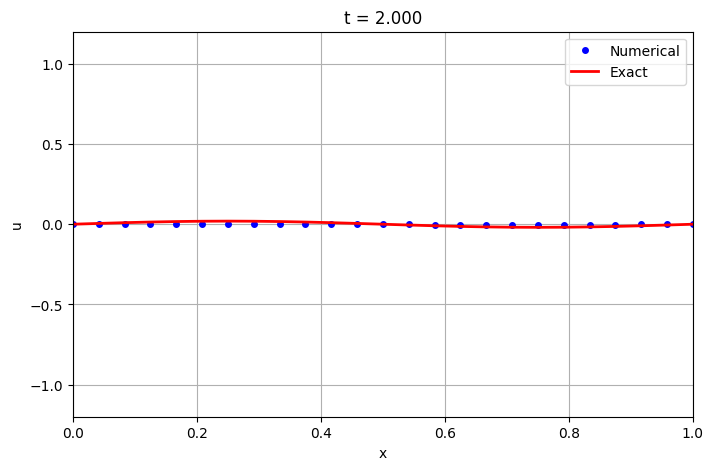

In [296]:
fig, ax = plt.subplots(figsize=(8,5))

num_line, = ax.plot([], [], 'bo',
                    markersize=4,
                    label='Numerical')

exact_line, = ax.plot([], [], 'r-',
                      lw=2,
                      label='Exact')

ax.set_xlim(0, L)
ax.set_ylim(-1.2, 1.2)

ax.set_xlabel('x')
ax.set_ylabel('u')

ax.grid(True)
ax.legend()

title = ax.set_title("")


def init():

    num_line.set_data([], [])
    exact_line.set_data([], [])

    return num_line, exact_line, title


def animate(frame):

    tframe = frame * dt

    unum = sol[frame]
    uex = uexact(x, tframe)

    num_line.set_data(x, unum)
    exact_line.set_data(x, uex)

    title.set_text(f't = {tframe:.3f}')

    return num_line, exact_line, title


ani = animation.FuncAnimation(
    fig,
    animate,
    frames=range(0, len(sol), 100),  # skip frames
    init_func=init,
    interval=3000,                   # slow motion
    blit=True
)

HTML(ani.to_jshtml())